In [ ]:
## 2026.02.11 using FineST env
## 2026.02.12 vilization cell type of each ROI
## 2026.03.04 woody_pro:: upload the HE-StarDist embedding and predict the cell type of NCRT_tumor1  
## 2026.03.06 woody_pro:: clearn code 
## 2026.03.13 update cell type level1: nanually make codex_meta_celltype_level1.csv 
## 2026.03.16 use valis to make registration [dont try]
## 2026.03.18 delete two subtypes, adjust scale factor by batch
## 2026.03.19 NCT

## Load anno data

In [2]:
import sys
import os
import pandas as pd
import importlib

## Add the code directory to Python path
path = '/home/lingyu/ssd2/Python/'
code_dir = f'{path}Hist2Pheno/code/Hist2Pheno_pkg'
if code_dir not in sys.path:
    sys.path.insert(0, code_dir)

## Import (or reload) base module
import base
import plot
## Impost：Force reload base.py
importlib.reload(base)  
importlib.reload(plot)  

## Re-import the function (otherwise, still be old_version).
from base import (
    get_celltype_coords,
    divide_into_rois_by_parent,
    get_pixel_size,
    visualize_roi_cells,
    visualize_all_rois_with_he,
    visualize_all_rois,
    extract_and_save_celltype_by_tumorid,
    transformation_matrix_properties,
    invert_transformation_matrix,
    align_pcf_to_he_coordinates,
    add_pixel_coords,
    verify_transformation_alignment,
    merge_coordinates,
    analyze_and_filter_classes_by_gap,
    ImprovedMLPClassifier,
    load_embeddings,
    match_embeddings,
    prepare_matched_embeddings,
    evaluate,
    plot_confusion_matrix,
    plot_per_class_f1,
    create_dataloaders,
    train_model,
    CellTypeDataset,
    evaluate_and_plot_on_all_data,
    align_matrix,
    match_StarCoords2ROI,
    match_celltype2stardist,
    merge_celltype_level12,
    make_PCF2HE_alignment
)

from plot import (
    plot_celltype_distribution,
    visualize_all_celltype_distributions,
    plot_celltype_distribution,
    plot_celltype_spatial_distribution,
    plot_PCF_HE_counts,
    plot_WSI_counts,
    plot_cell_area_histogram
)

## Import HAS_OPENSLIDE and HAS_TIFFFILE from base module for use in notebook
HAS_OPENSLIDE = base.HAS_OPENSLIDE
HAS_TIFFFILE = base.HAS_TIFFFILE

## Also import openslide module if available (needed for direct use in some cells)
if HAS_OPENSLIDE:
    import openslide
else:
    openslide = None

try:
    import tifffile
except ImportError:
    tifffile = None

print("Successfully reloaded functions from base.py")
print(f"openslide: {HAS_OPENSLIDE}, tifffile: {HAS_TIFFFILE}")


## reset pathway
os.chdir(f'{path}Hist2Pheno/data/CODEX/ESCC')
therapy_data = 'NCT'
segment_data1 = 'NCT_project -seg_1-14'
segment_data2 = 'NCT_project -seg_15-28'
export_data = 'export'
save_result = 'result'

/ssd2/users/lingyu/conda_envs/FineST/lib/python3.8/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Successfully reloaded functions from base.py
openslide: True, tifffile: True


### Load GT

In [3]:
celltype_level2_path = f'{path}Hist2Pheno/data/CODEX/ESCC/codex_meta_celltype.csv'
celltype_level1_path = f'{path}Hist2Pheno/data/CODEX/ESCC/codex_meta_celltype_level1.csv'
celltype_anno_path = f'{path}Hist2Pheno/data/CODEX/ESCC/codex_meta_celltype_final.csv'
# celltype_anno_df = merge_celltype_level12(celltype_level1_path, celltype_level2_path, celltype_anno_path, run=True)
celltype_anno_df = merge_celltype_level12(celltype_level1_path, celltype_level2_path, celltype_anno_path, run=False)
celltype_anno_df.head()

The number of cells after deleting 'Low_quality' and 'non_specific' cells: 10365126
The number of cell types level2: 40
The number of cell types level1: 7


,Unnamed: 0,CellID,TumorID,celltype,celltype_level1
0,S_1,38b0fa79-483d-4a28-be51-50967be5dcdb,S_tumor2,Treg,CD4+T
1,S_2,cd3415e0-f771-41aa-8691-8ba7c8bd0622,S_tumor2,Bn,B
2,S_3,f7fa5bf3-e070-423c-8012-2ac7e066f456,S_tumor2,B_other,B
3,S_4,3e7ca82c-4f00-474d-b74c-5db5abf42dd7,S_tumor2,B_other,B
4,S_5,a6beba40-b49e-4597-ab1a-8d1f2061163a,S_tumor2,B_other,B


In [4]:
celltype_coords_df1 = pd.read_csv(f'{therapy_data}/{segment_data1}/{export_data}/{therapy_data}-measurements-tumor1-14.csv')
celltype_coords_df2 = pd.read_csv(f'{therapy_data}/{segment_data2}/{export_data}/{therapy_data}-measurements-tumor-15-28.csv')
celltype_coords_df = pd.concat([celltype_coords_df1, celltype_coords_df2], ignore_index=True)
print("Cell numbers of 1-14:", celltype_coords_df1.shape)
print("Cell numbers of 15-28:", celltype_coords_df2.shape)
print("Cell numbers of 1-28:", celltype_coords_df.shape)
celltype_coords_df.head()

Cell numbers of 1-14: (1308395, 58)
Cell numbers of 15-28: (1146103, 58)
Cell numbers of 1-28: (2454498, 58)


,Image,Object ID,Name,Class,Parent,ROI,Centroid X µm,Centroid Y µm,Detection probability,Nucleus: Area µm^2,...,PD-1: Cell: Mean,CD14: Cell: Mean,CD27: Cell: Mean,CD123: Cell: Mean,Granzyme B: Cell: Mean,c-PARP: Nucleus: Mean,CD38: Cell: Mean,LAG3: Cell: Mean,TCF-1: Nucleus: Mean,PD-L1: Cell: Mean
0,NCT PCF.qptiff - resolution #1,620859c6-13e8-41ac-a982-f3d1035a0f12,PathCellObject,NaN,tumor3,Polygon,13146.9,633.98,0.9093,16.2824,...,49.2603,148.2397,2.1438,7.5205,1.5479,7.8125,26.8493,43.1164,73.5469,9.5685
1,NCT PCF.qptiff - resolution #1,510f6d4f-ba01-4fb2-bba7-6c435b7017a7,PathCellObject,NaN,tumor3,Polygon,13023.9,635.26,0.8341,12.3260,...,131.6429,418.1071,52.1429,59.0268,0.0000,17.8750,6.9464,97.0982,386.0417,35.4107
2,NCT PCF.qptiff - resolution #1,23c7c9f2-3511-460c-a77a-3ca8df5b6a4c,PathCellObject,NaN,tumor3,Polygon,13124.8,635.44,0.7781,8.4831,...,31.5135,106.5946,2.3108,4.8784,0.0405,5.7778,180.6351,79.8108,126.0833,21.8243
3,NCT PCF.qptiff - resolution #1,51bbdc6d-9c55-4356-8b0b-7d60e2f6666b,PathCellObject,NaN,tumor3,Polygon,13160.3,636.61,0.8901,12.6601,...,77.7619,269.9238,2.1429,6.4000,0.1619,11.8431,6.5810,43.5048,214.2353,24.0381
4,NCT PCF.qptiff - resolution #1,038c8bb4-9a7b-46dd-af8b-27cd0051fcf1,PathCellObject,NaN,tumor3,Polygon,13114.2,638.47,0.8320,26.9588,...,66.8952,137.4498,1.9563,6.0873,0.3799,10.6881,4.2882,85.3755,195.4037,16.8734


In [5]:
print("The number of ROIs", len(celltype_anno_df['TumorID'].unique()))
celltype_NCT_tumor1 = celltype_anno_df[celltype_anno_df['TumorID'] == 'NCT_tumor1']
print("The number of cells in NCT_tumor1", celltype_NCT_tumor1.shape[0])
celltype_NCT_tumor1.head()

The number of ROIs 140
The number of cells in NCT_tumor1 92707


,Unnamed: 0,CellID,TumorID,celltype,celltype_level1
3310355,NCT_706176,750389cf-da83-4b8d-94af-6857bb832972,NCT_tumor1,B_other,B
3310356,NCT_706177,9d5d32ae-33bd-416d-b60f-db93b842e2cc,NCT_tumor1,Neutrophil,Myeloid
3310357,NCT_706178,1ed5f966-4ce2-4ef6-a3b7-7857036ff547,NCT_tumor1,CD4_Tex,CD4+T
3310358,NCT_706179,f62e9cb6-d018-4802-9dfd-43a759bc173b,NCT_tumor1,CD4_Tex,CD4+T
3310359,NCT_706180,8a14f12f-bfc0-444c-a0a0-9ca50ddb2e79,NCT_tumor1,B_other,B


In [6]:
# ## extract and save cell type information for all TumorIDs
# saved_files_info = extract_and_save_celltype_by_tumorid(celltype_anno_df, base_path=f'{path}Hist2Pheno/data/CODEX/ESCC/')

In [7]:
# ## Call the function to batch visualize all folders
# visualize_all_celltype_distributions(base_path=f'{path}Hist2Pheno/data/CODEX/ESCC/codex_celltype')

The number of cells in celltype: 10365126
The distribution of celltype: celltype
CD8_Tpex                 1329760
Muscle&mCAF              1197496
CAF_other                 853404
Treg                      813448
Tumor_PDL1pos_MHCIpos     770217
Plasma                    738198
Endothelial               537909
Epithelial                496437
CD4_Tex                   418058
Monocyte                  385513
Macro_other               288451
Tumor_PDL1neg_MHCIpos     239810
Neutrophil                231752
CD8_Tex                   208595
Bm_unswitched             150591
Bm_switched               136771
Tumor_PDL1neg_MHCIneg     135267
Th17                      113394
CAF_ap                    109152
pDC                       105455
DC_mature                 100480
B_other                   100161
Tumor_PDL1pos_MHCIneg      88774
B_proliferating            79780
CD8_Teff                   79152
CD8_Tem                    74785
CD4_Tem                    67175
Macro_M1                   6

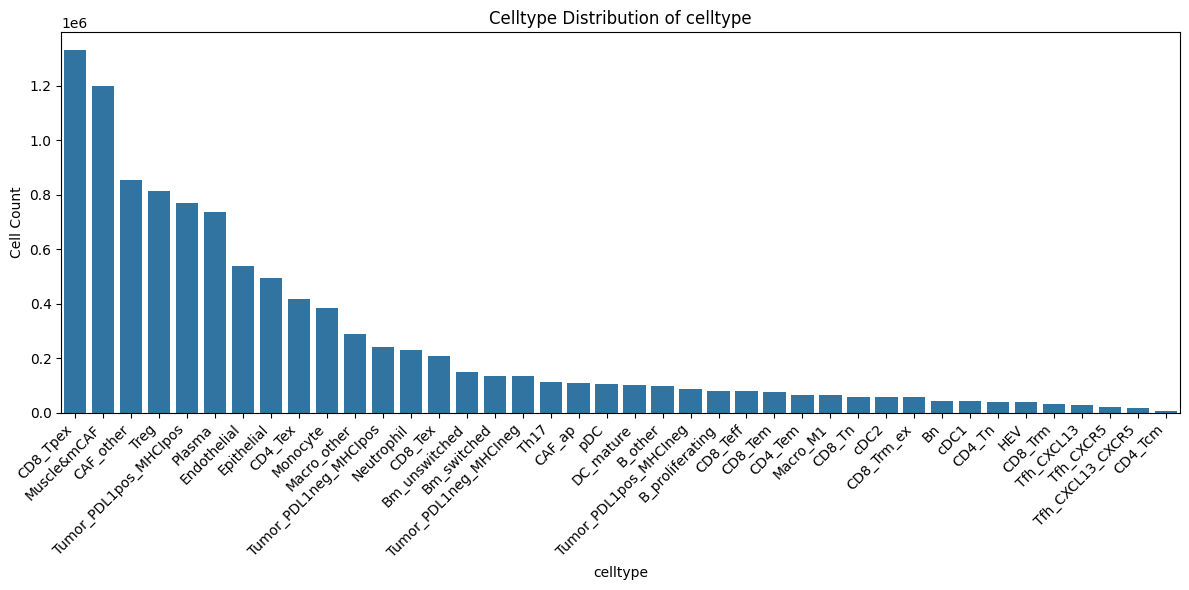

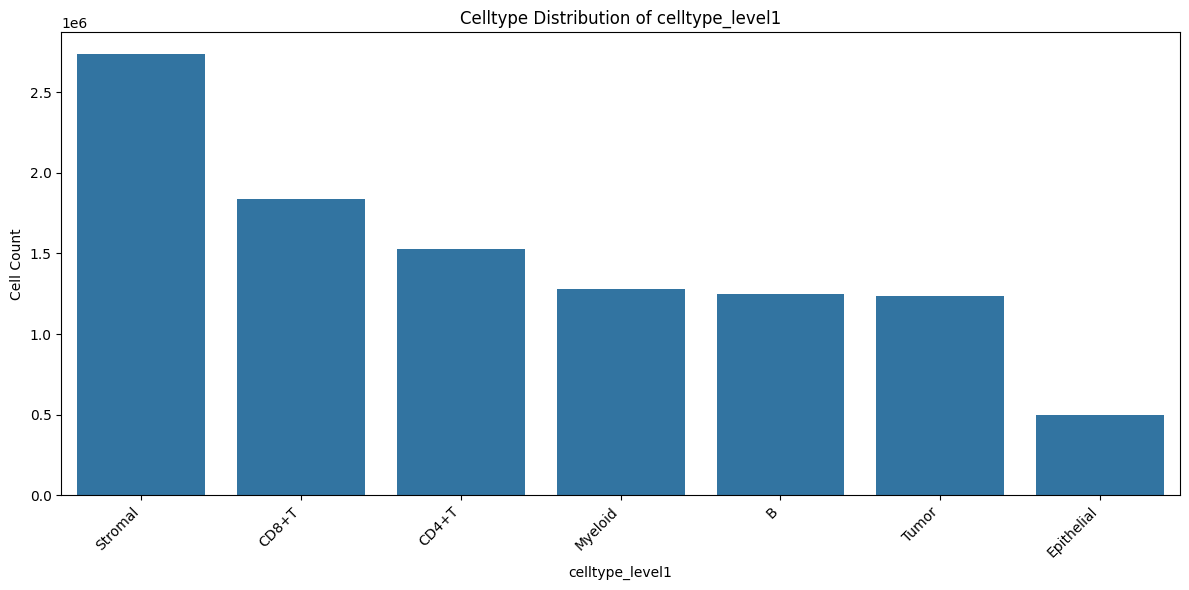

In [ ]:
plot_celltype_distribution(celltype_anno_df, 
                            celltype_col='celltype',
                            save_path=None)
                            # save_path=f'{therapy_data}/{save_result}/celltype_dist_level2.pdf')

plot_celltype_distribution(celltype_anno_df, 
                            celltype_col='celltype_level1',
                            save_path=None)
                            # save_path=f'{therapy_data}/{save_result}/celltype_dist_level1.pdf')

The number of cells in celltype: 92707
The distribution of celltype: celltype
Tumor_PDL1pos_MHCIneg    20527
CD8_Tpex                 12420
Tumor_PDL1pos_MHCIpos     8753
CD4_Tex                   8735
Neutrophil                7903
Muscle&mCAF               5077
Endothelial               4178
Plasma                    3291
Treg                      3213
CAF_other                 3183
Macro_M1                  2302
Monocyte                  1736
pDC                       1164
Th17                      1143
Bm_switched               1111
DC_mature                 1074
CD8_Trm_ex                1031
Macro_other                778
Tfh_CXCL13                 620
Bm_unswitched              549
Tumor_PDL1neg_MHCIneg      541
CD8_Tex                    485
B_other                    313
CAF_ap                     299
cDC2                       285
HEV                        281
B_proliferating            268
Tfh_CXCR5                  227
cDC1                       208
CD4_Tn                 

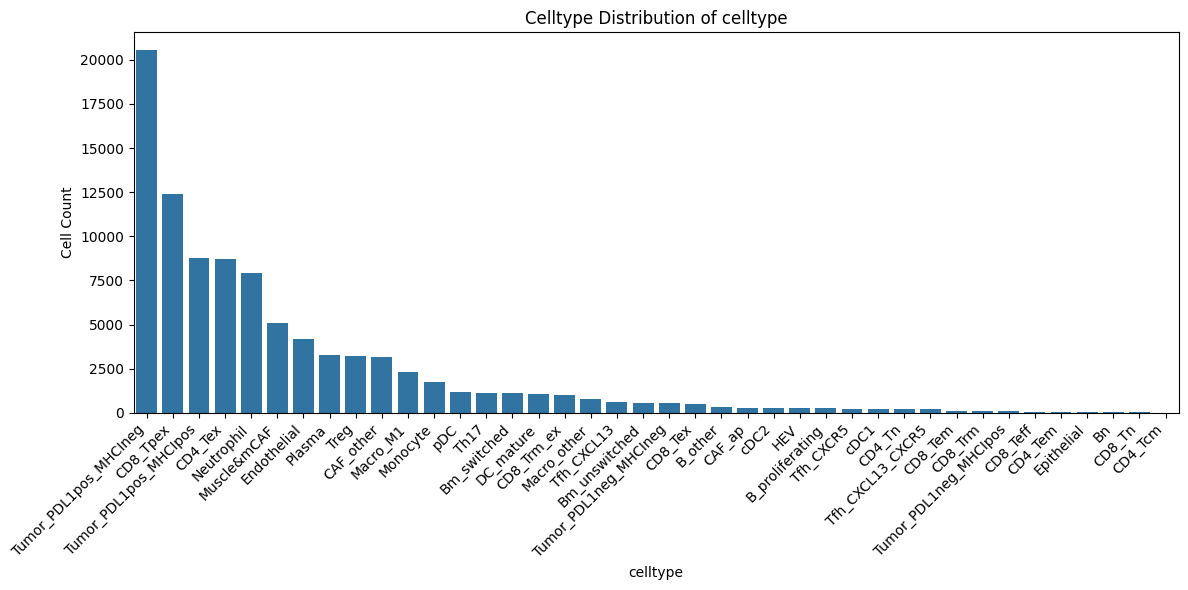

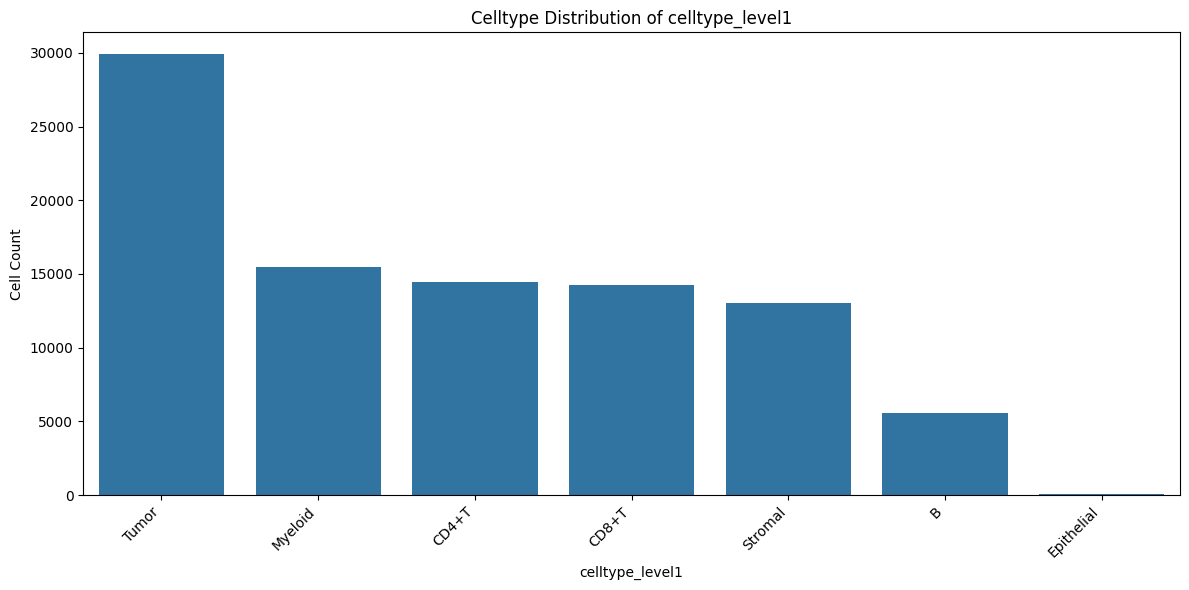

In [8]:
plot_celltype_distribution(celltype_NCT_tumor1, 
                            celltype_col='celltype',
                            # save_path=None)
                            save_path=f'{therapy_data}/{save_result}/celltype_dist_tumor1_level2.pdf')

plot_celltype_distribution(celltype_NCT_tumor1, 
                            celltype_col='celltype_level1',
                            # save_path=None)
                            save_path=f'{therapy_data}/{save_result}/celltype_dist_tumor1_level1.pdf')


Summary Statistics for 'Cell: Area µm^2':
  Total cells: 1,308,395
  Mean: 58.60 µm²
  Median: 52.75 µm²
  Standard deviation: 34.84 µm²
  Range: [2.81, 3160.05] µm²
  IQR: [33.98, 74.68] µm²

Summary Statistics for 'Cell: Area µm^2':
  Total cells: 1,146,103
  Mean: 57.11 µm²
  Median: 51.24 µm²
  Standard deviation: 35.08 µm²
  Range: [2.23, 4186.62] µm²
  IQR: [33.18, 72.55] µm²

Summary Statistics for 'Cell: Area µm^2':
  Total cells: 2,454,498
  Mean: 57.90 µm²
  Median: 52.04 µm²
  Standard deviation: 34.96 µm²
  Range: [2.23, 4186.62] µm²
  IQR: [33.59, 73.68] µm²


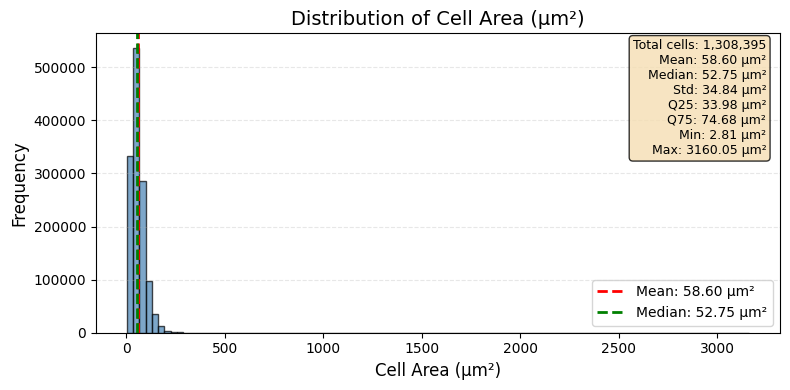

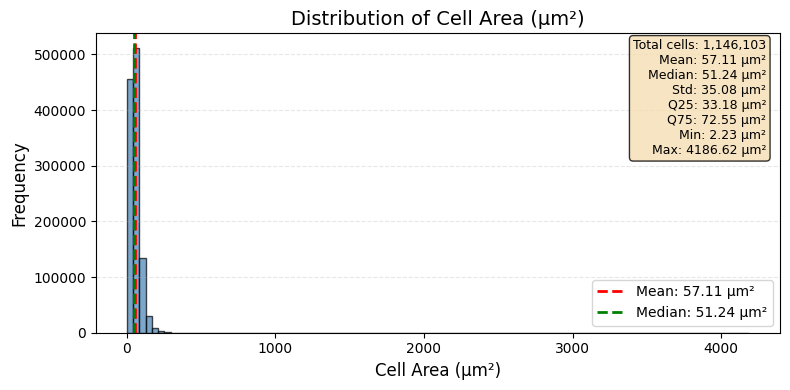

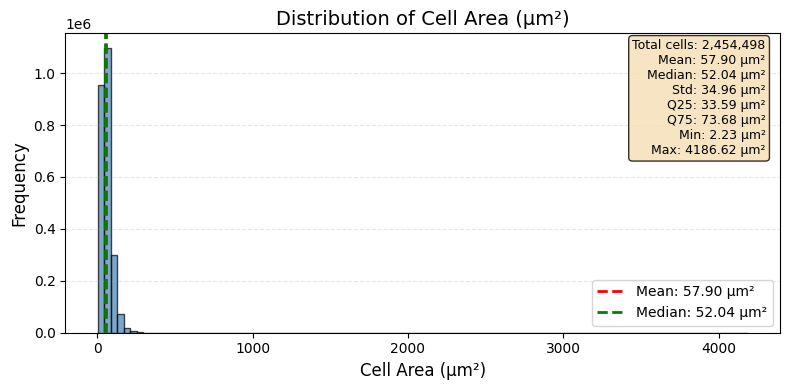

In [10]:
plot_cell_area_histogram(celltype_coords_df1, 
                        # save_path=None)
                        save_path=f'{therapy_data}/{save_result}/cellarea_dist_1_14.pdf')
plot_cell_area_histogram(celltype_coords_df2, 
                        # save_path=None)
                        save_path=f'{therapy_data}/{save_result}/cellarea_dist_15_28.pdf')
plot_cell_area_histogram(celltype_coords_df, 
                        # save_path=None)
                        save_path=f'{therapy_data}/{save_result}/cellarea_dist.pdf')

In [14]:
## celltype_NCRT_tumor1
celltype_NCT_tumor1 = get_celltype_coords(celltype_anno_df, celltype_coords_df, value='NCT_tumor1', parent_value='tumor1')
celltype_NCT_tumor1.head()

['Unnamed: 0', 'CellID', 'TumorID', 'celltype', 'celltype_level1']
Before filtering - ncrt_anno_df1 shape: (2454498, 58)
Unique Parent values:
 ['tumor3' 'tumor6' 'tumor7' 'tumor8' 'tumor9' 'tumor10' 'tumor2' 'tumor1'
 'tumor4' 'tumor5' 'tumor11' 'tumor12' 'tumor13' 'tumor14' 'tumor16'
 'tumor17' 'tumor18' 'tumor21' 'tumor23' 'tumor25' 'tumor26' 'tumor27'
 'tumor15' 'tumor19' 'tumor20' 'tumor22' 'tumor24' 'tumor28']
After filtering for 'tumor1' - ncrt_anno_df1_tumor1 shape: (103385, 58)
Number of cells in tumor1: 103385

Shape of celltype_NCRT_tumor1 before merging: (92707, 5)
Shape of ncrt_anno_df1_tumor1: (103385, 58)
Shape of celltype_NCRT_tumor1 after merging: (92707, 7)

Columns after merging: ['Unnamed: 0', 'CellID', 'TumorID', 'celltype', 'celltype_level1', 'Centroid X µm', 'Centroid Y µm']
Successfully matched cells: 92707 / 92707 (100.00%)


,Unnamed: 0,CellID,TumorID,celltype,celltype_level1,Centroid X µm,Centroid Y µm
0,NCT_706176,750389cf-da83-4b8d-94af-6857bb832972,NCT_tumor1,B_other,B,2095.2,388.66
1,NCT_706177,9d5d32ae-33bd-416d-b60f-db93b842e2cc,NCT_tumor1,Neutrophil,Myeloid,2101.2,392.85
2,NCT_706178,1ed5f966-4ce2-4ef6-a3b7-7857036ff547,NCT_tumor1,CD4_Tex,CD4+T,2107.1,395.01
3,NCT_706179,f62e9cb6-d018-4802-9dfd-43a759bc173b,NCT_tumor1,CD4_Tex,CD4+T,2094.5,399.41
4,NCT_706180,8a14f12f-bfc0-444c-a0a0-9ca50ddb2e79,NCT_tumor1,B_other,B,2111.4,401.61


### Visualization CODEX tumorX

Number of valid data points: 92707
Number of cell types: 40


(<Figure size 1200x1000 with 1 Axes>,
 <Axes: title={'center': 'celltype Spatial Distribution'}, xlabel='Centroid X µm', ylabel='Centroid Y µm'>)

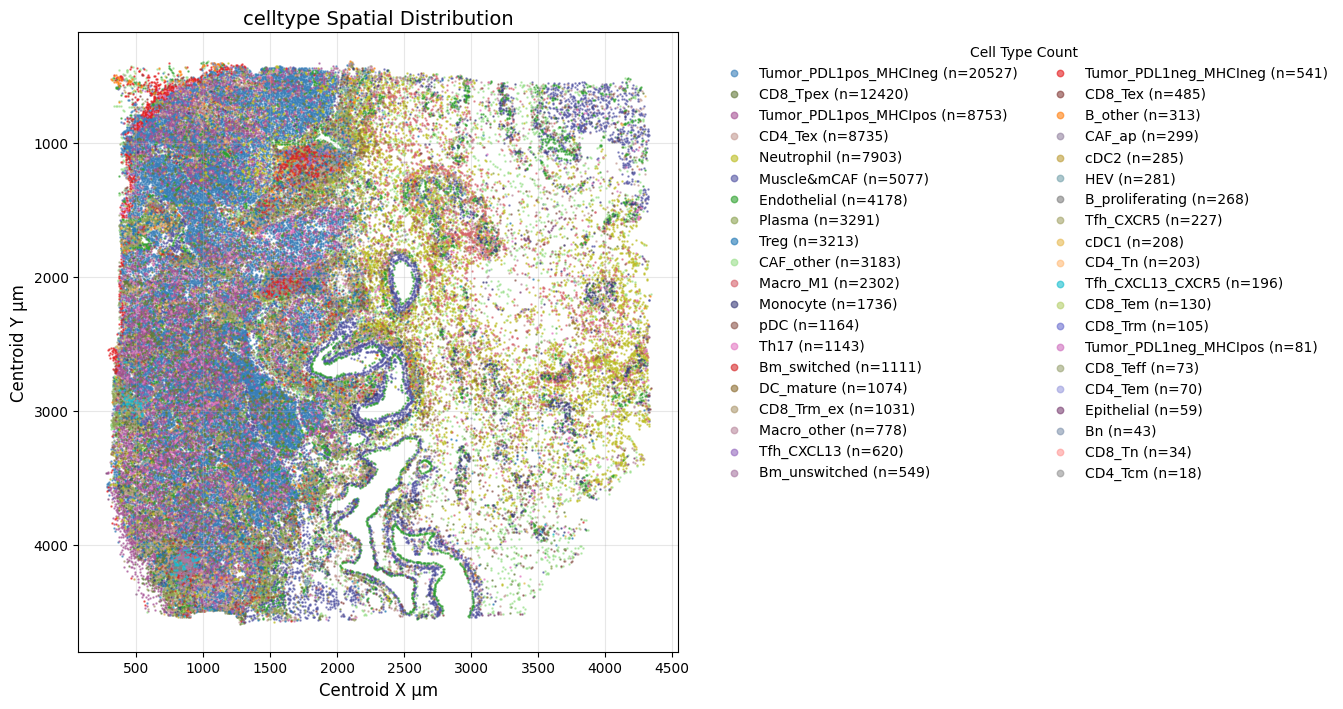

In [15]:
## Plot the spatial distribution of cell types in celltype_NCRT_tumor1
plot_celltype_spatial_distribution(celltype_NCT_tumor1,
                                   x_col='Centroid X µm', y_col='Centroid Y µm',
                                   celltype_col='celltype',
                                   figsize=(12, 10), alpha=0.6,s=0.6,
                                    # format='jpg', save_path=None)
                                    format='jpg', save_path=f'{therapy_data}/{save_result}/celltype_spatial_tumor1_level2.jpg')

Number of valid data points: 92707
Number of cell types: 40


(<Figure size 1200x1000 with 1 Axes>,
 <Axes: title={'center': 'celltype_level1 Spatial Distribution'}, xlabel='Centroid X µm', ylabel='Centroid Y µm'>)

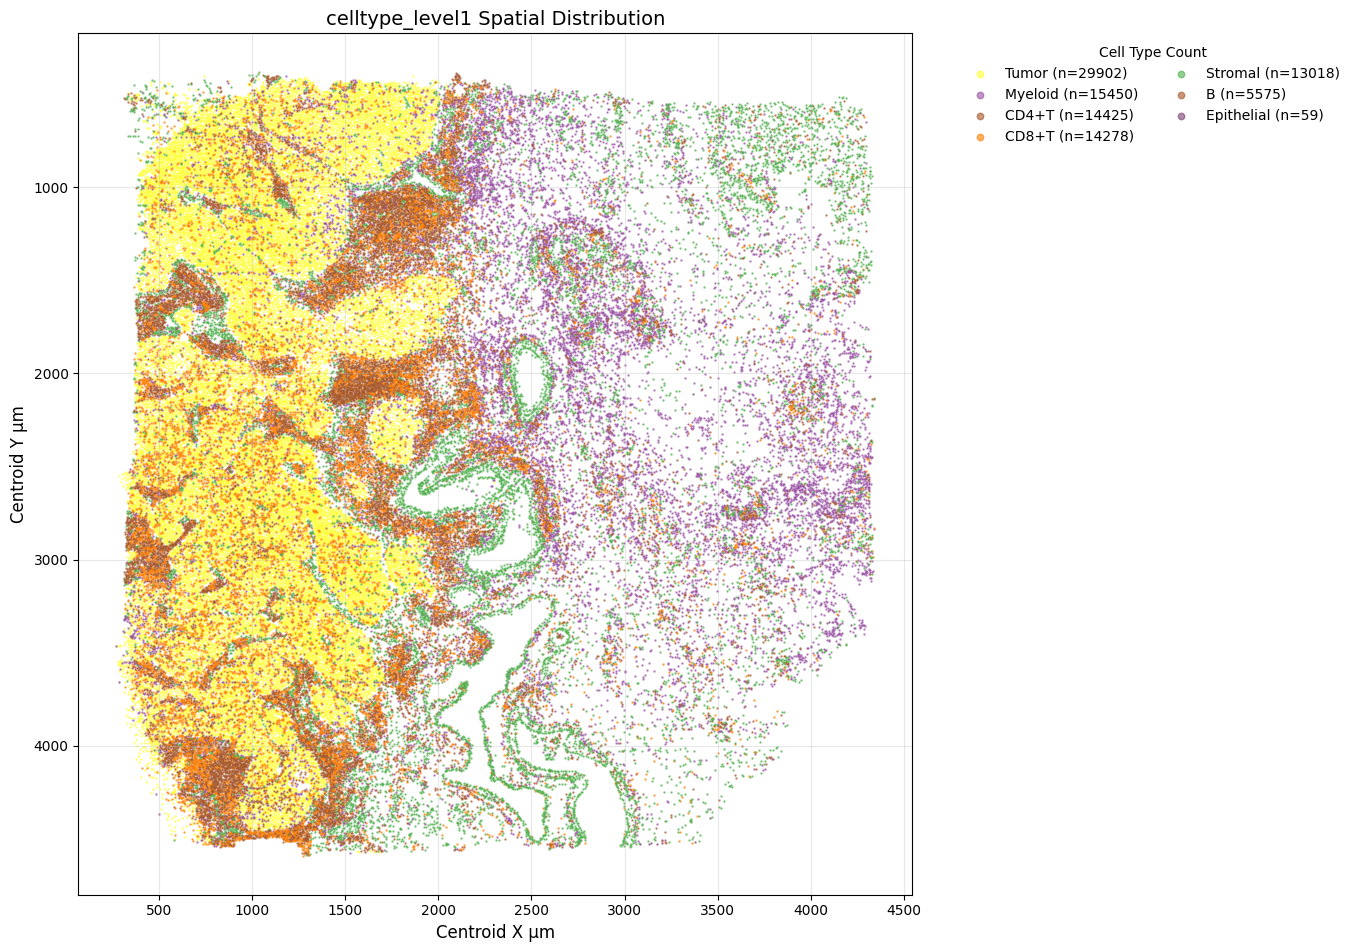

In [16]:
plot_celltype_spatial_distribution(celltype_NCT_tumor1,
                                   x_col='Centroid X µm', y_col='Centroid Y µm',
                                   celltype_col='celltype_level1',
                                   figsize=(12, 10), alpha=0.6,s=0.6,
                                    # format='jpg', save_path=None)
                                    format='jpg', save_path=f'{therapy_data}/{save_result}/celltype_spatial_tumor1_level1.jpg')

['Unnamed: 0', 'CellID', 'TumorID', 'celltype', 'celltype_level1']
Before filtering - ncrt_anno_df1 shape: (1308395, 58)
Unique Parent values:
 ['tumor3' 'tumor6' 'tumor7' 'tumor8' 'tumor9' 'tumor10' 'tumor2' 'tumor1'
 'tumor4' 'tumor5' 'tumor11' 'tumor12' 'tumor13' 'tumor14']
After filtering for 'tumor5' - ncrt_anno_df1_tumor1 shape: (95921, 58)
Number of cells in tumor5: 95921

Shape of celltype_NCRT_tumor1 before merging: (94415, 5)
Shape of ncrt_anno_df1_tumor1: (95921, 58)
Shape of celltype_NCRT_tumor1 after merging: (94415, 7)

Columns after merging: ['Unnamed: 0', 'CellID', 'TumorID', 'celltype', 'celltype_level1', 'Centroid X µm', 'Centroid Y µm']
Successfully matched cells: 94415 / 94415 (100.00%)
Number of valid data points: 94415
Number of cell types: 40
Number of valid data points: 94415
Number of cell types: 40


(<Figure size 1200x1000 with 1 Axes>,
 <Axes: title={'center': 'celltype_level1 Spatial Distribution'}, xlabel='Centroid X µm', ylabel='Centroid Y µm'>)

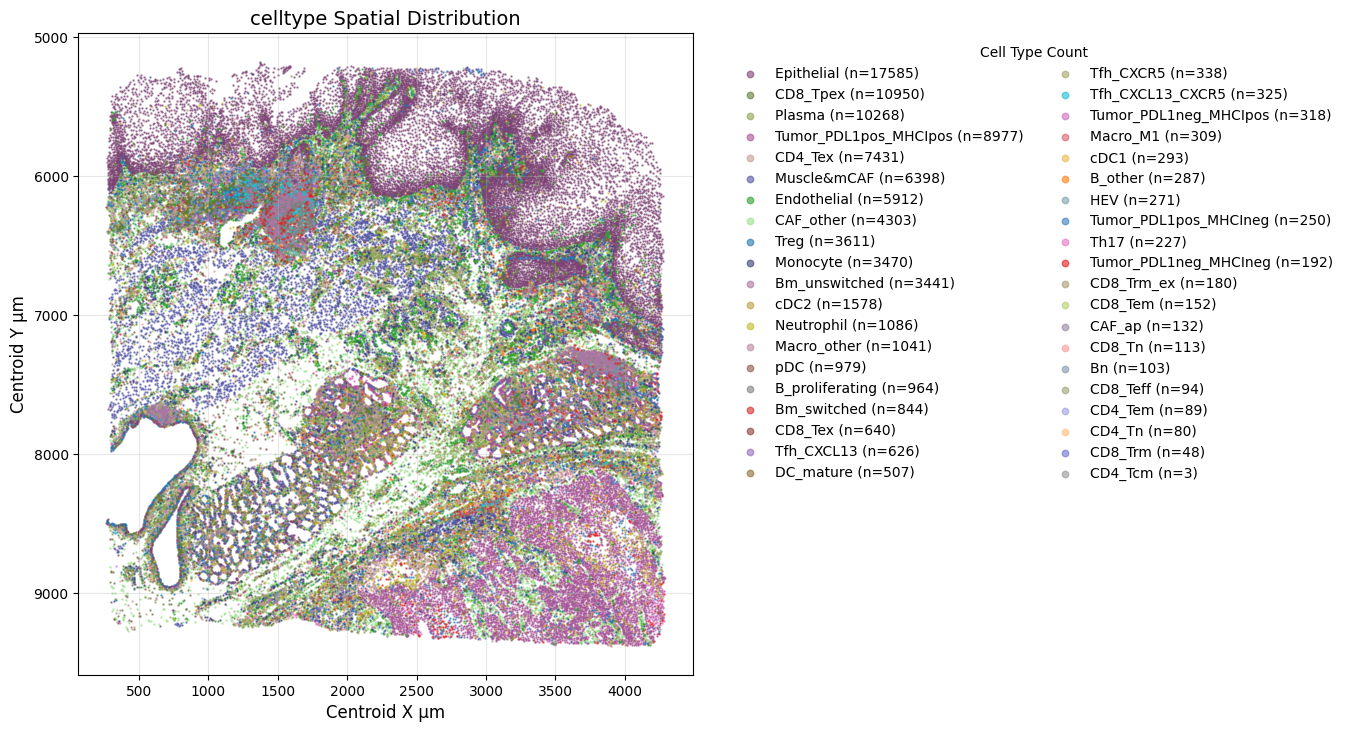

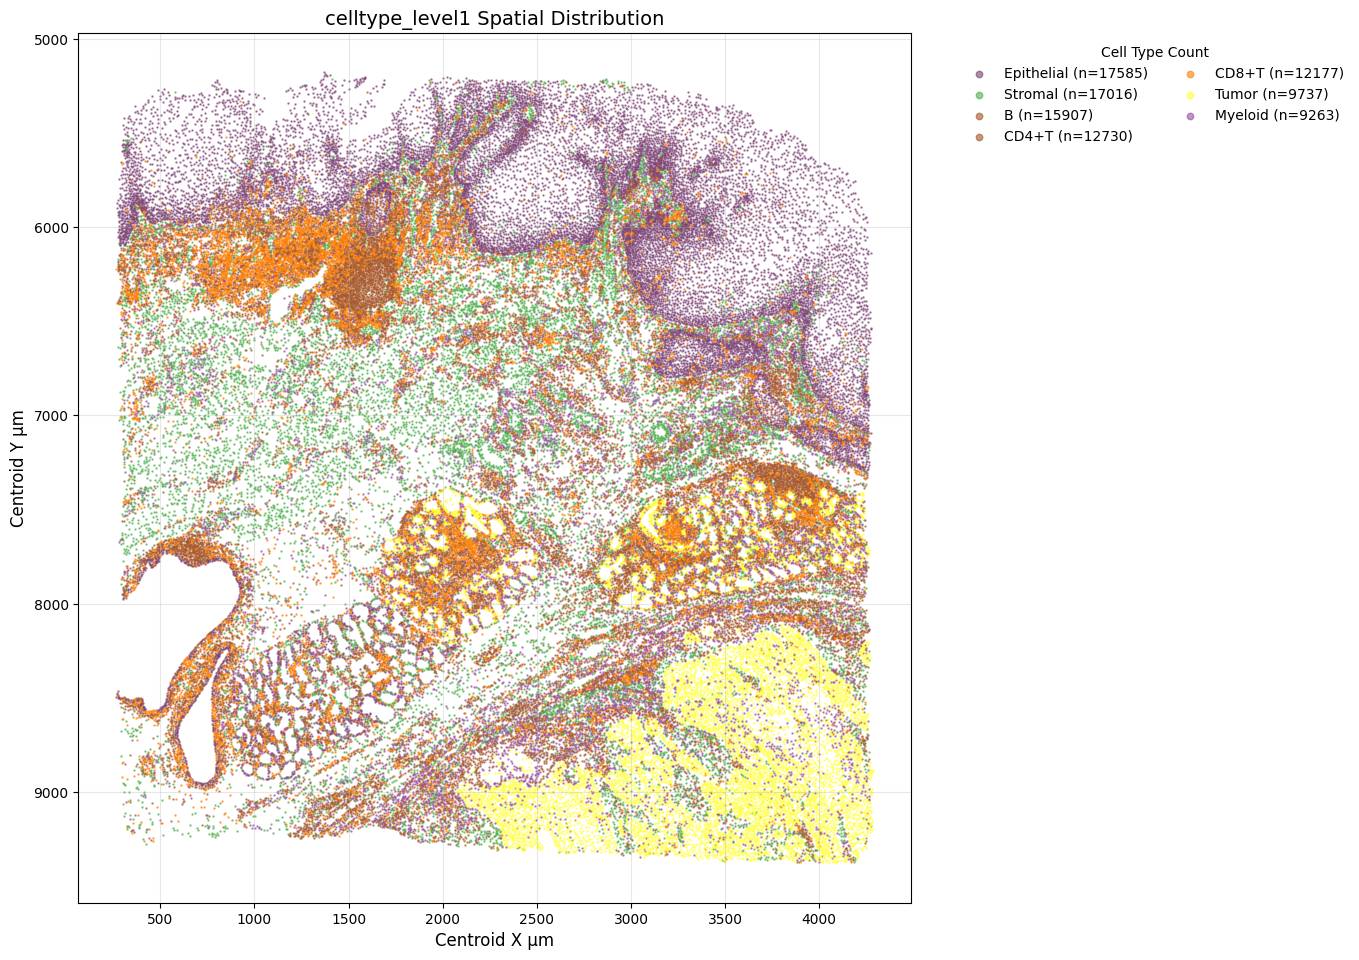

In [18]:
## celltype_NCRT_tumor5
celltype_NCT_tumor5 = get_celltype_coords(celltype_anno_df, celltype_coords_df1, value='NCT_tumor5', parent_value='tumor5')
# celltype_NCRT_tumor5.head()
plot_celltype_spatial_distribution(celltype_NCT_tumor5,
                                   x_col='Centroid X µm', y_col='Centroid Y µm',
                                   celltype_col='celltype',
                                   figsize=(12, 10), alpha=0.6,s=0.6,
                                   # format='jpg', save_path=None)  
                                    format='jpg', save_path=f'{therapy_data}/{save_result}/celltype_spatial_tumor5_level2.jpg')
plot_celltype_spatial_distribution(celltype_NCT_tumor5,
                                   x_col='Centroid X µm', y_col='Centroid Y µm',
                                   celltype_col='celltype_level1',
                                   figsize=(12, 10), alpha=0.6,s=0.6,
                                   # format='jpg', save_path=None)  
                                    format='jpg', save_path=f'{therapy_data}/{save_result}/celltype_spatial_tumor5_level1.jpg')

### Alignment: Coordinates transform: PCF -> HE

- Transformation matrix exported from QuPath: [up: HE; down: PCF]
- Here, In QuPath, NCRT PCF.qptiff is the reference (front) and NCRT HE.qptiff is the target (back)
- QuPath shows HE->PCF, we need PCF->HE (INVERT the matrix)

In [19]:
## Load images
he_path  = f'{path}Hist2Pheno/data/CODEX/ESCC/{therapy_data}/NCRT HE.qptiff'
pcf_path = f'{path}Hist2Pheno/data/CODEX/ESCC/{therapy_data}/NCRT PCF.qptiff'
segment_path = f'{path}Hist2Pheno/data/CODEX/ESCC/{therapy_data}/{segment_data1}'
he_cell_coords_path = f'{path}Hist2Pheno/data/CODEX/ESCC/he_cell_coords/{therapy_data}_CellPixCoords.csv'
he_cell_coords4ViT_path = f'{path}Hist2Pheno/data/CODEX/ESCC/he_cell_coords/{therapy_data}_CellPixCoords4ViT.csv'

he_cell_coords_tumor1_path = f'{path}Hist2Pheno/data/CODEX/ESCC/he_cell_coords/{therapy_data}_CellPixCoords_tumor1.csv'
he_cell_coords4ViT_tumor1_path = f'{path}Hist2Pheno/data/CODEX/ESCC/he_cell_coords/{therapy_data}_CellPixCoords4ViT_tumor1.csv'

In [20]:
####################################
# celltype_pixel_NCRT
####################################
celltype_pixel_NCT = make_PCF2HE_alignment(celltype_anno_df, celltype_coords_df, 
                                            therapy_data, segment_path, 
                                            segment_batch1='1', segment_batch2='2', 
                                            value='NCT', parent_value=None,
                                            save_path=he_cell_coords_path, save_path4ViT=he_cell_coords4ViT_path)
                                            # save_path=None, save_path4ViT=None)

Original QuPath matrix (HE -> PCF):
[[ 9.83707582e-01 -1.21905687e-02 -3.12213303e+03]
 [ 1.21905687e-02  9.83707582e-01 -1.88234665e+02]]

Matrix properties (HE -> PCF):
  Scale: 0.9837, Rotation: 0.6985°
  Translation: X=-3122.1, Y=-188.2

Inverted matrix (PCF -> HE):
[[ 1.01640616e+00  1.25957849e-02  3.17572622e+03]
 [-1.25957849e-02  1.01640616e+00  1.51997157e+02]]

Matrix properties (PCF -> HE):
  Scale: 1.0165, Rotation: -0.7217°
  Translation: X=3175.7, Y=152.0
pixel_size_um read from server.json: 0.508248 µm
width read from server.json: 35520
height read from server.json: 65520
pixel_size_um read from server.json: 0.500006 µm
width read from server.json: 40320
height read from server.json: 67680
['Unnamed: 0', 'CellID', 'TumorID', 'celltype', 'celltype_level1']
Dont filtering - parent value: 'Parent' column
Available columns: ['Image', 'CellID', 'Name', 'Class', 'Parent', 'ROI', 'Centroid X µm', 'Centroid Y µm', 'Detection probability', 'Nucleus: Area µm^2']
Shape of celltype

In [21]:
print("Cell numbers with NCT:", celltype_pixel_NCT.shape[0])
celltype_pixel_NCT.head()

Cell numbers with NCT: 2327271


,Unnamed: 0,CellID,TumorID,celltype,celltype_level1,Centroid X µm,Centroid Y µm,X_pix_PCF,Y_pix_PCF,X_pix_HE,Y_pix_HE,X_um_HE,Y_um_HE
0,NCT_2,510f6d4f-ba01-4fb2-bba7-6c435b7017a7,NCT_tumor3,Endothelial,Stromal,13023.9,635.26,25625.071374,1249.900786,29236.950192,1099.636132,14618.654484,549.824813
1,NCT_3,23c7c9f2-3511-460c-a77a-3ca8df5b6a4c,NCT_tumor3,Plasma,B,13124.8,635.44,25823.596371,1250.254943,29438.736683,1097.495521,14719.548968,548.754495
2,NCT_4,51bbdc6d-9c55-4356-8b0b-7d60e2f6666b,NCT_tumor3,CAF_ap,Stromal,13160.3,636.61,25893.444115,1252.556967,29509.759357,1098.955526,14755.060741,549.484506
3,NCT_5,038c8bb4-9a7b-46dd-af8b-27cd0051fcf1,NCT_tumor3,Muscle&mCAF,Stromal,13114.2,638.47,25802.740425,1256.216596,29417.613663,1103.817679,14708.987328,551.915612
4,NCT_7,248e2e7f-07bf-4a85-b9bc-7fe8ac9b509d,NCT_tumor3,Plasma,B,13018.8,639.49,25615.036910,1258.223489,29226.855932,1108.221770,14613.607292,554.117685


In [22]:
####################################
# celltype_pixel_NCT
####################################
celltype_pixel_NCT_tumor1 = make_PCF2HE_alignment(celltype_anno_df, celltype_coords_df, 
                                            therapy_data, segment_path, 
                                            segment_batch1='1', segment_batch2='2', 
                                            value='NCT', parent_value='tumor1',
                                            save_path=he_cell_coords_tumor1_path, save_path4ViT=he_cell_coords4ViT_tumor1_path)
                                            # save_path=None, save_path4ViT=None)

Original QuPath matrix (HE -> PCF):
[[ 9.83707582e-01 -1.21905687e-02 -3.12213303e+03]
 [ 1.21905687e-02  9.83707582e-01 -1.88234665e+02]]

Matrix properties (HE -> PCF):
  Scale: 0.9837, Rotation: 0.6985°
  Translation: X=-3122.1, Y=-188.2

Inverted matrix (PCF -> HE):
[[ 1.01640616e+00  1.25957849e-02  3.17572622e+03]
 [-1.25957849e-02  1.01640616e+00  1.51997157e+02]]

Matrix properties (PCF -> HE):
  Scale: 1.0165, Rotation: -0.7217°
  Translation: X=3175.7, Y=152.0
pixel_size_um read from server.json: 0.508248 µm
width read from server.json: 35520
height read from server.json: 65520
pixel_size_um read from server.json: 0.500006 µm
width read from server.json: 40320
height read from server.json: 67680
['Unnamed: 0', 'CellID', 'TumorID', 'celltype', 'celltype_level1']
Before filtering - ncrt_anno_df1 shape: (2454498, 58)
Unique Parent values:
 ['tumor3' 'tumor6' 'tumor7' 'tumor8' 'tumor9' 'tumor10' 'tumor2' 'tumor1'
 'tumor4' 'tumor5' 'tumor11' 'tumor12' 'tumor13' 'tumor14' 'tumor16

In [23]:
print("Cell numbers with NCT tumor1:", celltype_pixel_NCT_tumor1.shape[0])
celltype_pixel_NCT_tumor1.head()

Cell numbers with NCT tumor1: 92707


,Unnamed: 0,CellID,TumorID,celltype,celltype_level1,Centroid X µm,Centroid Y µm,X_pix_PCF,Y_pix_PCF,X_pix_HE,Y_pix_HE,X_um_HE,Y_um_HE
0,NCT_706176,750389cf-da83-4b8d-94af-6857bb832972,NCT_tumor1,B_other,B,2095.2,388.66,4122.394179,764.704907,7375.385129,877.323148,3687.737817,438.666957
1,NCT_706177,9d5d32ae-33bd-416d-b60f-db93b842e2cc,NCT_tumor1,Neutrophil,Myeloid,2101.2,392.85,4134.199431,772.948908,7387.487900,885.553705,3693.789277,442.782286
2,NCT_706178,1ed5f966-4ce2-4ef6-a3b7-7857036ff547,NCT_tumor1,CD4_Tex,CD4+T,2107.1,395.01,4145.807929,777.198799,7399.340380,889.727102,3699.715590,444.869010
3,NCT_706179,f62e9cb6-d018-4802-9dfd-43a759bc173b,NCT_tumor1,CD4_Tex,CD4+T,2094.5,399.41,4121.016899,785.855985,7374.251668,898.838581,3687.171080,449.424806
4,NCT_706180,8a14f12f-bfc0-444c-a0a0-9ca50ddb2e79,NCT_tumor1,B_other,B,2111.4,401.61,4154.268360,790.184577,7408.103180,902.819361,3704.097044,451.415220


## HIPT

<!-- ## Option A: Using HIPT (recommended for quick start, no token required)
python ./demo/Image_feature_extraction.py \
   --dataset NPC \
   --position_path FineST_tutorial_data/spatial/tissue_positions_list.csv \
   --rawimage_path FineST_tutorial_data/20210809-C-AH4199551.tif \
   --scale_image False \
   --method HIPT \
   --patch_size 64 \
   --output_img FineST_tutorial_data/ImgEmbeddings/pth_64_16_image \
   --output_pth FineST_tutorial_data/ImgEmbeddings/pth_64_16 \
   --logging FineST_tutorial_data/ImgEmbeddings/Logging/ \
   --scale 0.5  # default is 0.5 -->

In [27]:
## Load celltype_pixel_NCRT
path = '/home/lingyu/ssd2/Python/'
therapy_data = 'NCRT'
celltype_pixel_NCRT = pd.read_csv(f'{path}Hist2Pheno/data/CODEX/ESCC/he_cell_coords/NCRT_CellPixCoords4ViT.csv')
celltype_pixel_NCRT.head()

,Unnamed: 0,CellID,TumorID,celltype,celltype_level1,Centroid X µm,Centroid Y µm,X_pix_PCF,Y_pix_PCF,pxl_row_in_fullres,pxl_col_in_fullres,X_um_HE,Y_um_HE
0,NCRT_1,e071bc4e-01bc-4831-a466-25be5330e3df,NCRT_tumor1,CAF_other,Stromal,4159.0,1.242,8183.007536,2.443687,13885.887175,2031.339753,6943.028787,1015.682340
1,NCRT_2,99103727-0736-484a-93b0-f83efe823c03,NCRT_tumor1,Neutrophil,Myeloid,3970.5,2.817,7812.125853,5.542566,13508.928169,2037.450502,6754.546971,1018.737752
2,NCRT_3,4882bef1-7690-443b-8e2c-512d3e81c77b,NCRT_tumor1,Monocyte,Myeloid,4027.5,2.793,7924.275751,5.495345,13622.922877,2036.507170,6811.545024,1018.266080
3,NCRT_4,1e0d319a-d7c0-4c2a-85d1-08cfc6e42523,NCRT_tumor1,CAF_other,Stromal,4172.1,3.086,8208.782337,6.071835,13912.115011,2034.821824,6956.142865,1017.423397
4,NCRT_5,ff987357-f306-42ab-8e03-233ac4f5e850,NCRT_tumor1,Monocyte,Myeloid,3996.6,3.635,7863.478701,7.152015,13561.138767,2038.676462,6780.652590,1019.350740


In [ ]:
# ## Option A: Using HIPT (recommended for quick start, no token required)
# %cd /home/lingyu/ssd2/Python/Hist2Pheno/
# !python code/Image_feature_extraction.py \
#    --dataset sc_NCRT \
#    --position_path data/he_cell_coords/NCRT_CellPixCoords4ViT_tumor1.csv \
#    --rawimage_path 'data/NCRT/NCRT HE.qptiff' \
#    --scale_image False \
#    --method HIPT \
#    --patch_size 16 \
#    --output_img data/NCRT/NCRT_project_tumor1/ImgEmbeddings_tumor1/sc_pth_16_16_image \
#    --output_pth data/NCRT/NCRT_project_tumor1/ImgEmbeddings_tumor1/sc_pth_16_16 \
#    --logging data/NCRT/NCRT_project_tumor1/ImgEmbeddings_tumor1/ \
#    --scale 0.5  

In [ ]:
# ## Option A: Using HIPT (recommended for quick start, no token required)
# %cd /home/lingyu/ssd2/Python/Hist2Pheno/
# !python code/Image_feature_extraction.py \
#    --dataset sc_NCT \
#    --position_path data/he_cell_coords/NCT_CellPixCoords4ViT.csv \
#    --rawimage_path 'data/NCT/NCT HE.qptiff' \
#    --scale_image False \
#    --method HIPT \
#    --patch_size 16 \
#    --output_img data/NCT/NCT_project_all/ImgEmbeddings_all/sc_pth_16_16_image \
#    --output_pth data/NCT/NCT_project_all/ImgEmbeddings_all/sc_pth_16_16 \
#    --logging data/NCT/NCT_project_all/ImgEmbeddings_all/ \
#    --scale 0.5  

In [ ]:
# ## Option A: Using HIPT (recommended for quick start, no token required)
# %cd /home/lingyu/ssd2/Python/Hist2Pheno/
# !python code/Image_feature_extraction.py \
#    --dataset sc_NICT \
#    --position_path data/he_cell_coords/NICT_CellPixCoords4ViT.csv \
#    --rawimage_path 'data/NICT/NICT HE.qptiff' \
#    --scale_image False \
#    --method HIPT \
#    --patch_size 16 \
#    --output_img data/NICT/NICT_project_all/ImgEmbeddings_all/sc_pth_16_16_image \
#    --output_pth data/NICT/NICT_project_all/ImgEmbeddings_all/sc_pth_16_16 \
#    --logging data/NICT/NICT_project_all/ImgEmbeddings_all/ \
#    --scale 0.5  

In [ ]:
# ## Option A: Using HIPT (recommended for quick start, no token required)
# %cd /home/lingyu/ssd2/Python/Hist2Pheno/
# !python code/Image_feature_extraction.py \
#    --dataset sc_SA \
#    --position_path data/he_cell_coords/SA_CellPixCoords4ViT.csv \
#    --rawimage_path 'data/SA/SA HE.qptiff' \
#    --scale_image False \
#    --method HIPT \
#    --patch_size 16 \
#    --output_img data/SA/SA_project_all/ImgEmbeddings_all/sc_pth_16_16_image \
#    --output_pth data/SA/SA_project_all/ImgEmbeddings_all/sc_pth_16_16 \
#    --logging data/SA/SA_project_all/ImgEmbeddings_all/ \
#    --scale 0.5  

[2026-03-18 19:49:09] INFO - tissue_position number: 80303
[2026-03-18 19:49:09] INFO - tissue_position range: 14916.687368292329 9578.480430557478
[2026-03-18 19:49:09] INFO - Loading image at original resolution (no scaling)
[2026-03-18 19:49:09] INFO - image_width, image_height: 47040, 70560
[2026-03-18 19:49:39] INFO - Image segmentation time: 29.98 seconds
[2026-03-18 19:49:39] INFO - Method: HIPT
[2026-03-18 19:56:19] INFO - Feature extraction time: 399.56 seconds